In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [2]:
credit_df = pd.read_csv(r"C:\Users\ni\Desktop\credit_risk_predictor\cleaned_data\credit_data.csv")
credit_df

,credit_limit,default,current_outstanding_balance,avg_bill_amount,total_paid,payment_ratio,num_late_payments,avg_delay,max_delay,recent_delay,credit_utilization
0,20000.0,1,3913.0,1284.000000,689.0,0.089422,2,-0.333333,2,2,0.195640
1,120000.0,1,2682.0,2846.166667,5000.0,0.292774,2,0.500000,2,-1,0.022350
2,90000.0,0,29239.0,16942.166667,11018.0,0.108387,0,0.000000,0,0,0.324874
3,50000.0,0,46990.0,38555.666667,8388.0,0.036259,0,0.000000,0,0,0.939781
4,50000.0,0,8617.0,18223.166667,59049.0,0.540049,0,-0.333333,0,-1,0.172337
...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,0,188948.0,120891.500000,42550.0,0.058661,0,0.000000,0,0,0.858851
29996,150000.0,0,1683.0,3530.333333,14490.0,0.684039,0,-0.666667,0,-1,0.011220
29997,30000.0,1,3565.0,11749.333333,31300.0,0.443991,3,1.333333,4,4,0.118829
29998,80000.0,1,-1645.0,44435.166667,147181.0,0.552042,1,-0.166667,1,1,-0.020562


In [3]:
# Split dataset into features (X) and target (y)

X = credit_df.drop("default", axis=1)
y = credit_df["default"]

In [4]:
"""
Split data into training and testing sets
"""

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
X_train

,credit_limit,current_outstanding_balance,avg_bill_amount,total_paid,payment_ratio,num_late_payments,avg_delay,max_delay,recent_delay,credit_utilization
22788,160000.0,161771.0,165490.000000,39500.0,0.039781,4,1.500000,3,2,1.011062
29006,150000.0,0.0,8.833333,53.0,0.981481,1,-1.166667,1,1,0.000000
16950,10000.0,10171.0,8576.833333,4016.0,0.078038,2,0.500000,2,1,1.016998
22280,220000.0,206879.0,186262.333333,41687.0,0.037301,0,0.000000,0,0,0.940355
11346,310000.0,0.0,30.333333,1526.0,8.338798,1,-0.666667,1,1,0.000000
...,...,...,...,...,...,...,...,...,...,...
23479,100000.0,91344.0,95067.500000,24051.0,0.042165,0,0.000000,0,0,0.913431
13921,120000.0,112336.0,116539.833333,26960.0,0.038556,1,0.333333,2,0,0.936126
3794,120000.0,75796.0,53654.166667,11939.0,0.037086,0,0.000000,0,0,0.631628
27565,360000.0,0.0,169.000000,1106.0,1.089655,1,-1.000000,1,1,0.000000


In [6]:
"""
Scale features for model training
"""

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
X_train_scaled

array([[-0.05686623,  1.50554693,  1.91467196, ...,  1.91112339,
         1.79331103,  1.43198247],
       [-0.13408117, -0.69516453, -0.7112067 , ...,  0.41766932,
         0.90294373, -1.03143896],
       [-1.21509034, -0.55679958, -0.57524846, ...,  1.16439636,
         0.90294373,  1.44644502],
       ...,
       [-0.36572599,  0.33595431,  0.14004507, ..., -0.32905771,
         0.01257644,  0.50750273],
       [ 1.48743258, -0.69516453, -0.70866515, ...,  0.41766932,
         0.90294373, -1.03143896],
       [ 1.02414294, -0.67821411, -0.70393909, ..., -1.07578475,
        -0.87779086, -1.02131952]], shape=(24000, 10))

In [8]:
"""
Convert scaled arrays back to DataFrames for better readability
"""

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

In [9]:
X_train_scaled

,credit_limit,current_outstanding_balance,avg_bill_amount,total_paid,payment_ratio,num_late_payments,avg_delay,max_delay,recent_delay,credit_utilization
22788,-0.056866,1.505547,1.914672,0.135198,-0.015835,2.040431,1.721333,1.911123,1.793311,1.431982
29006,-0.134081,-0.695165,-0.711207,-0.532239,-0.015100,0.105940,-1.005498,0.417669,0.902944,-1.031439
16950,-1.215090,-0.556800,-0.575248,-0.465185,-0.015806,0.750771,0.698772,1.164396,0.902944,1.446445
22280,0.406423,2.119190,2.244290,0.172202,-0.015837,-0.538890,0.187491,-0.329058,0.012576,1.259706
11346,1.101358,-0.695165,-0.710866,-0.507316,-0.009353,0.105940,-0.494217,0.417669,0.902944,-1.031439
...,...,...,...,...,...,...,...,...,...,...
23479,-0.520156,0.547467,0.797198,-0.126196,-0.015834,-0.538890,0.187491,-0.329058,0.012576,1.194106
13921,-0.365726,0.833040,1.137924,-0.076977,-0.015836,0.105940,0.528345,1.164396,0.012576,1.249401
3794,-0.365726,0.335954,0.140045,-0.331130,-0.015838,-0.538890,0.187491,-0.329058,0.012576,0.507503
27565,1.487433,-0.695165,-0.708665,-0.514422,-0.015015,0.105940,-0.835071,0.417669,0.902944,-1.031439


In [10]:
"""
Train Logistic Regression model ( Baseline Model )
"""

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
"""
Make predictions on test set
"""

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [12]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(6000,))

In [13]:
y_prob

array([0.12487989, 0.13511127, 0.15032866, ..., 0.09269165, 0.12862763,
       0.1115242 ], shape=(6000,))

In [14]:
"""
Evaluate model performance
"""

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8083333333333333
Precision: 0.6487394957983194
Recall: 0.2908816880180859
F1 Score: 0.4016649323621228


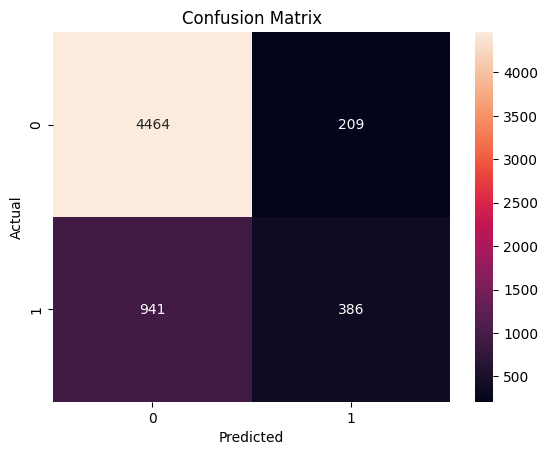

In [15]:
"""
Confusion matrix visualization
"""

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
"""
The model achieves good overall accuracy, but recall for defaulters is relatively low. 
This indicates that while the model performs well in identifying non-defaulters, 
it misses a significant portion of risky customers. 
Improving recall is critical for real-world deployment.
""";

In [17]:
"""
Train and evaluate Logistic Regression model with optional class weighting
"""

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def train_evaluate_logreg(X_train, X_test, y_train, y_test, class_weight=None, threshold=0.5):
    
    # Initialize model
    model = LogisticRegression(class_weight=class_weight, max_iter=1000)
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Apply custom threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n=== Model Results (class_weight={class_weight}, threshold={threshold}) ===")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Confusion Matrix (threshold={threshold})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return model


=== Model Results (class_weight=balanced, threshold=0.5) ===
Accuracy: 0.7378333333333333
Precision: 0.43358531317494603
Recall: 0.6051243406179352
F1 Score: 0.5051903114186851


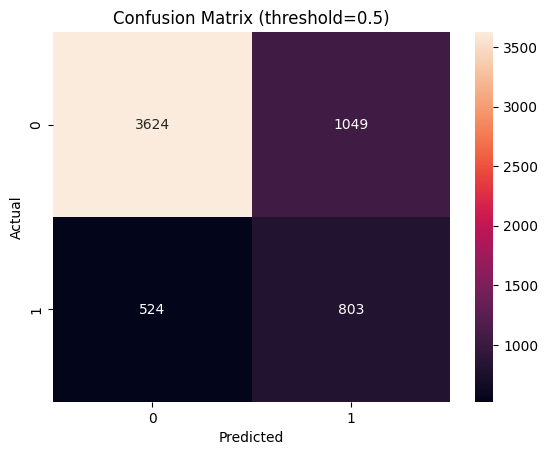

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [18]:
train_evaluate_logreg(
    X_train_scaled, X_test_scaled, y_train, y_test,
    class_weight='balanced'
)

In [19]:
"""
To address class imbalance, we applied class weighting, which significantly improved recall from 29% to 60%. 
This allowed the model to identify a much higher proportion of risky customers,
making it more suitable for real-world credit risk applications, despite a slight reduction in overall accuracy.
""";

In [20]:
"""
Train and evaluate Logistic Regression with customizable parameters
"""

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def train_evaluate_logreg(
    X_train, X_test, y_train, y_test,
    class_weight=None,
    threshold=0.5,
    C=1.0,
    solver="lbfgs"
):
    
    # Initialize model with parameters
    model = LogisticRegression(
        class_weight=class_weight,
        C=C,
        solver=solver,
        max_iter=1000
    )
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Apply threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n=== Results (C={C}, solver={solver}, class_weight={class_weight}, threshold={threshold}) ===")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    
    # Confusion Matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Confusion Matrix")
    plt.show()
    
    return model


=== Results (C=1.0, solver=lbfgs, class_weight=balanced, threshold=0.3) ===
Accuracy: 0.43366666666666664
Precision: 0.26662159116520173
Recall: 0.8914845516201959
F1 Score: 0.4104788341429563


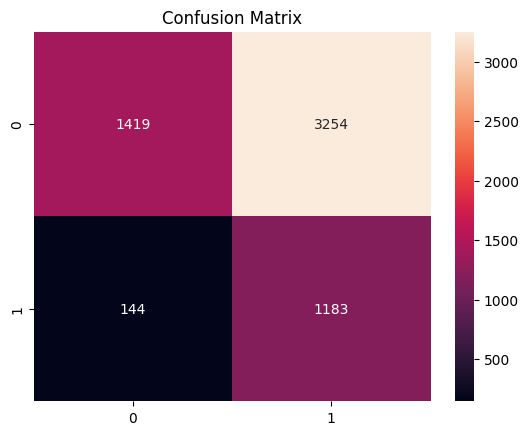

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [21]:
train_evaluate_logreg(
    X_train_scaled, X_test_scaled, y_train, y_test,
    class_weight="balanced",
    threshold=0.3
)

In [10]:
"""
Train Random Forest model
"""

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [11]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4673
           1       0.50      0.57      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000



In [13]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob_rf)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7738007676415896


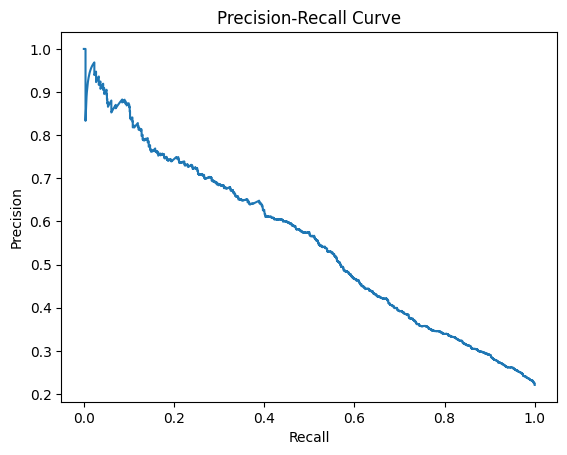

In [14]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [30]:
"""
Hyperparameter tuning for Random Forest (optimized for ROC-AUC)
"""

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

def tune_random_forest(X_train, y_train):
    
    param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [8, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
        "class_weight": [None, "balanced"]
    }
    
    rf = RandomForestClassifier(random_state=42)
    
    grid = GridSearchCV(
        rf,
        param_grid,
        cv=3,  # keep 3 for speed
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X_train, y_train)
    
    print("Best Parameters:", grid.best_params_)
    print("Best ROC-AUC (CV):", grid.best_score_)
    
    return grid.best_estimator_

In [31]:
best_rf = tune_random_forest(X_train, y_train)

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'class_weight': None, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best ROC-AUC (CV): 0.7845148719749871


ROC-AUC: 0.7800602508824684
PR-AUC: 0.5626778967912803


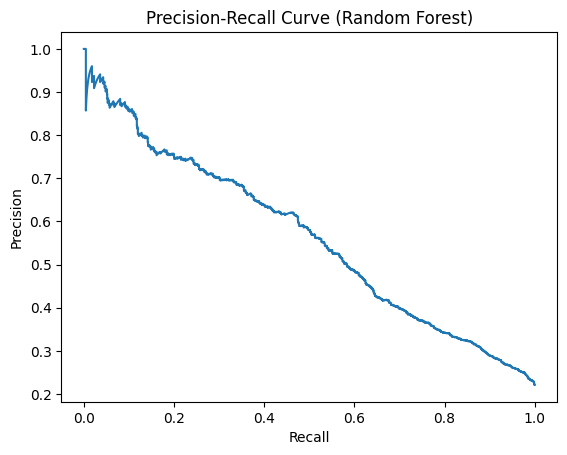

In [33]:
"""
Evaluate tuned Random Forest model
"""

from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Probabilities
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_rf)
print("ROC-AUC:", roc_auc)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

# Plot PR Curve
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest)")
plt.show()

In [15]:
"""
Improved baseline XGBoost model
"""

from xgboost import XGBClassifier

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [16]:
from sklearn.metrics import classification_report, roc_auc_score

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4673
           1       0.46      0.63      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.76      0.77      6000

ROC-AUC: 0.7803073049800591


In [17]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [18]:
"""
Ensemble using weighted average (soft voting)
"""

ensemble_prob = (0.6 * rf_prob) + (0.4 * xgb_prob)

In [19]:
y_pred_ens = (ensemble_prob >= 0.5).astype(int)

In [20]:
print(classification_report(y_test, y_pred_ens))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      4673
           1       0.49      0.59      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000



In [21]:
roc_auc = roc_auc_score(y_test, ensemble_prob)
print("Ensemble ROC-AUC:", roc_auc)

Ensemble ROC-AUC: 0.7779136055691026


In [22]:
import numpy as np

class CreditEnsembleModel:
    def __init__(self, rf_model, xgb_model, w_rf=0.6, w_xgb=0.4):
        self.rf_model = rf_model
        self.xgb_model = xgb_model
        self.w_rf = w_rf
        self.w_xgb = w_xgb

    def predict_proba(self, X):
        rf_prob = self.rf_model.predict_proba(X)[:, 1]
        xgb_prob = self.xgb_model.predict_proba(X)[:, 1]
        
        ensemble_prob = (self.w_rf * rf_prob) + (self.w_xgb * xgb_prob)
        
        return np.vstack([1 - ensemble_prob, ensemble_prob]).T

    def predict(self, X):
        prob = self.predict_proba(X)[:, 1]
        return (prob >= 0.5).astype(int)

In [23]:
ensemble_model = CreditEnsembleModel(rf_model, xgb_model)

In [24]:
y_pred_ens = ensemble_model.predict(X_test)
y_prob_ens = ensemble_model.predict_proba(X_test)[:, 1]

In [25]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

print(classification_report(y_test, y_pred_ens))
print("Accuracy:", accuracy_score(y_test, y_pred_ens))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_ens))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      4673
           1       0.49      0.59      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000

Accuracy: 0.7735
ROC-AUC: 0.7779136055691026


In [31]:
# Saving the final ensembled model to load into Flask microservice.

import joblib

path = r"C:\Users\ni\Desktop\credit_risk_predictor\final_model\credit_ensemble.pkl"

joblib.dump(ensemble_model, path)

['C:\\Users\\ni\\Desktop\\credit_risk_predictor\\final_model\\credit_ensemble.pkl']

In [39]:
with open("ensemble_model.py", "w") as f:
    f.write("""
import numpy as np

class CreditEnsembleModel:
    def __init__(self, rf_model, xgb_model, w_rf=0.6, w_xgb=0.4):
        self.rf_model = rf_model
        self.xgb_model = xgb_model
        self.w_rf = w_rf
        self.w_xgb = w_xgb

    def predict_proba(self, X):
        rf_prob = self.rf_model.predict_proba(X)[:, 1]
        xgb_prob = self.xgb_model.predict_proba(X)[:, 1]
        
        ensemble_prob = (self.w_rf * rf_prob) + (self.w_xgb * xgb_prob)
        
        return np.vstack([1 - ensemble_prob, ensemble_prob]).T

    def predict(self, X):
        prob = self.predict_proba(X)[:, 1]
        return (prob >= 0.5).astype(int)
""")

C:\Users\ni\Desktop\credit_risk_predictor\notebooks


In [36]:
import joblib
from ensemble_model import CreditEnsembleModel  # where your class is

model = joblib.load(r"C:\Users\ni\Desktop\credit_risk_predictor\final_model\credit_ensemble.pkl")

# test prediction
sample = X_test[:5]
print(model.predict(sample))

[0 0 0 0 0]


In [40]:
X_train.columns

Index(['credit_limit', 'current_outstanding_balance', 'avg_bill_amount', 'total_paid', 'payment_ratio', 'num_late_payments', 'avg_delay', 'max_delay', 'recent_delay', 'credit_utilization'], dtype='object')